In [1]:
import sys
sys.path.append("../../../src")


In [22]:
import pandas as pd
import numpy as np
import pre_processamento as pp
import plotar_graficos as pg
import experimentos as exp
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report



In [24]:
import importlib
importlib.reload(pg)


<module 'plotar_graficos' from 'c:\\Users\\tteve\\OneDrive\\Área de Trabalho\\UFC\\2025.2\\CIÊNCIA DOS DADOS\\modelo\\notebooks\\T3\\Classificação\\../../../src\\plotar_graficos.py'>

In [4]:
dataset = pd.read_csv('../../../data/raw/diabetes_dataset.csv')

In [5]:
dataset

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


In [6]:
# Informações gerais sobre o dataset
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [7]:
dataset.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [8]:
#Separação do dataset em categórico e numero para fazer o tratamento do categórico
df_num, df_cat = pp.separar_numericos_categoricos(dataset)

#Fazendo o tratamento dos dados categóricos aplicando o one-hot encoding
df_categorico_num = pp.tratar_categoricos_como_numericos(df_cat)

#Juntar os dados em um dataset unico
dataset = pp.juntar_numericos_e_categoricos(df_num,df_categorico_num)

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   alcohol_consumption_per_week        100000 non-null  int64  
 2   physical_activity_minutes_per_week  100000 non-null  int64  
 3   diet_score                          100000 non-null  float64
 4   sleep_hours_per_day                 100000 non-null  float64
 5   screen_time_hours_per_day           100000 non-null  float64
 6   family_history_diabetes             100000 non-null  int64  
 7   hypertension_history                100000 non-null  int64  
 8   cardiovascular_history              100000 non-null  int64  
 9   bmi                                 100000 non-null  float64
 10  waist_to_hip_ratio                  100000 non-null  float64
 11  systolic_bp                

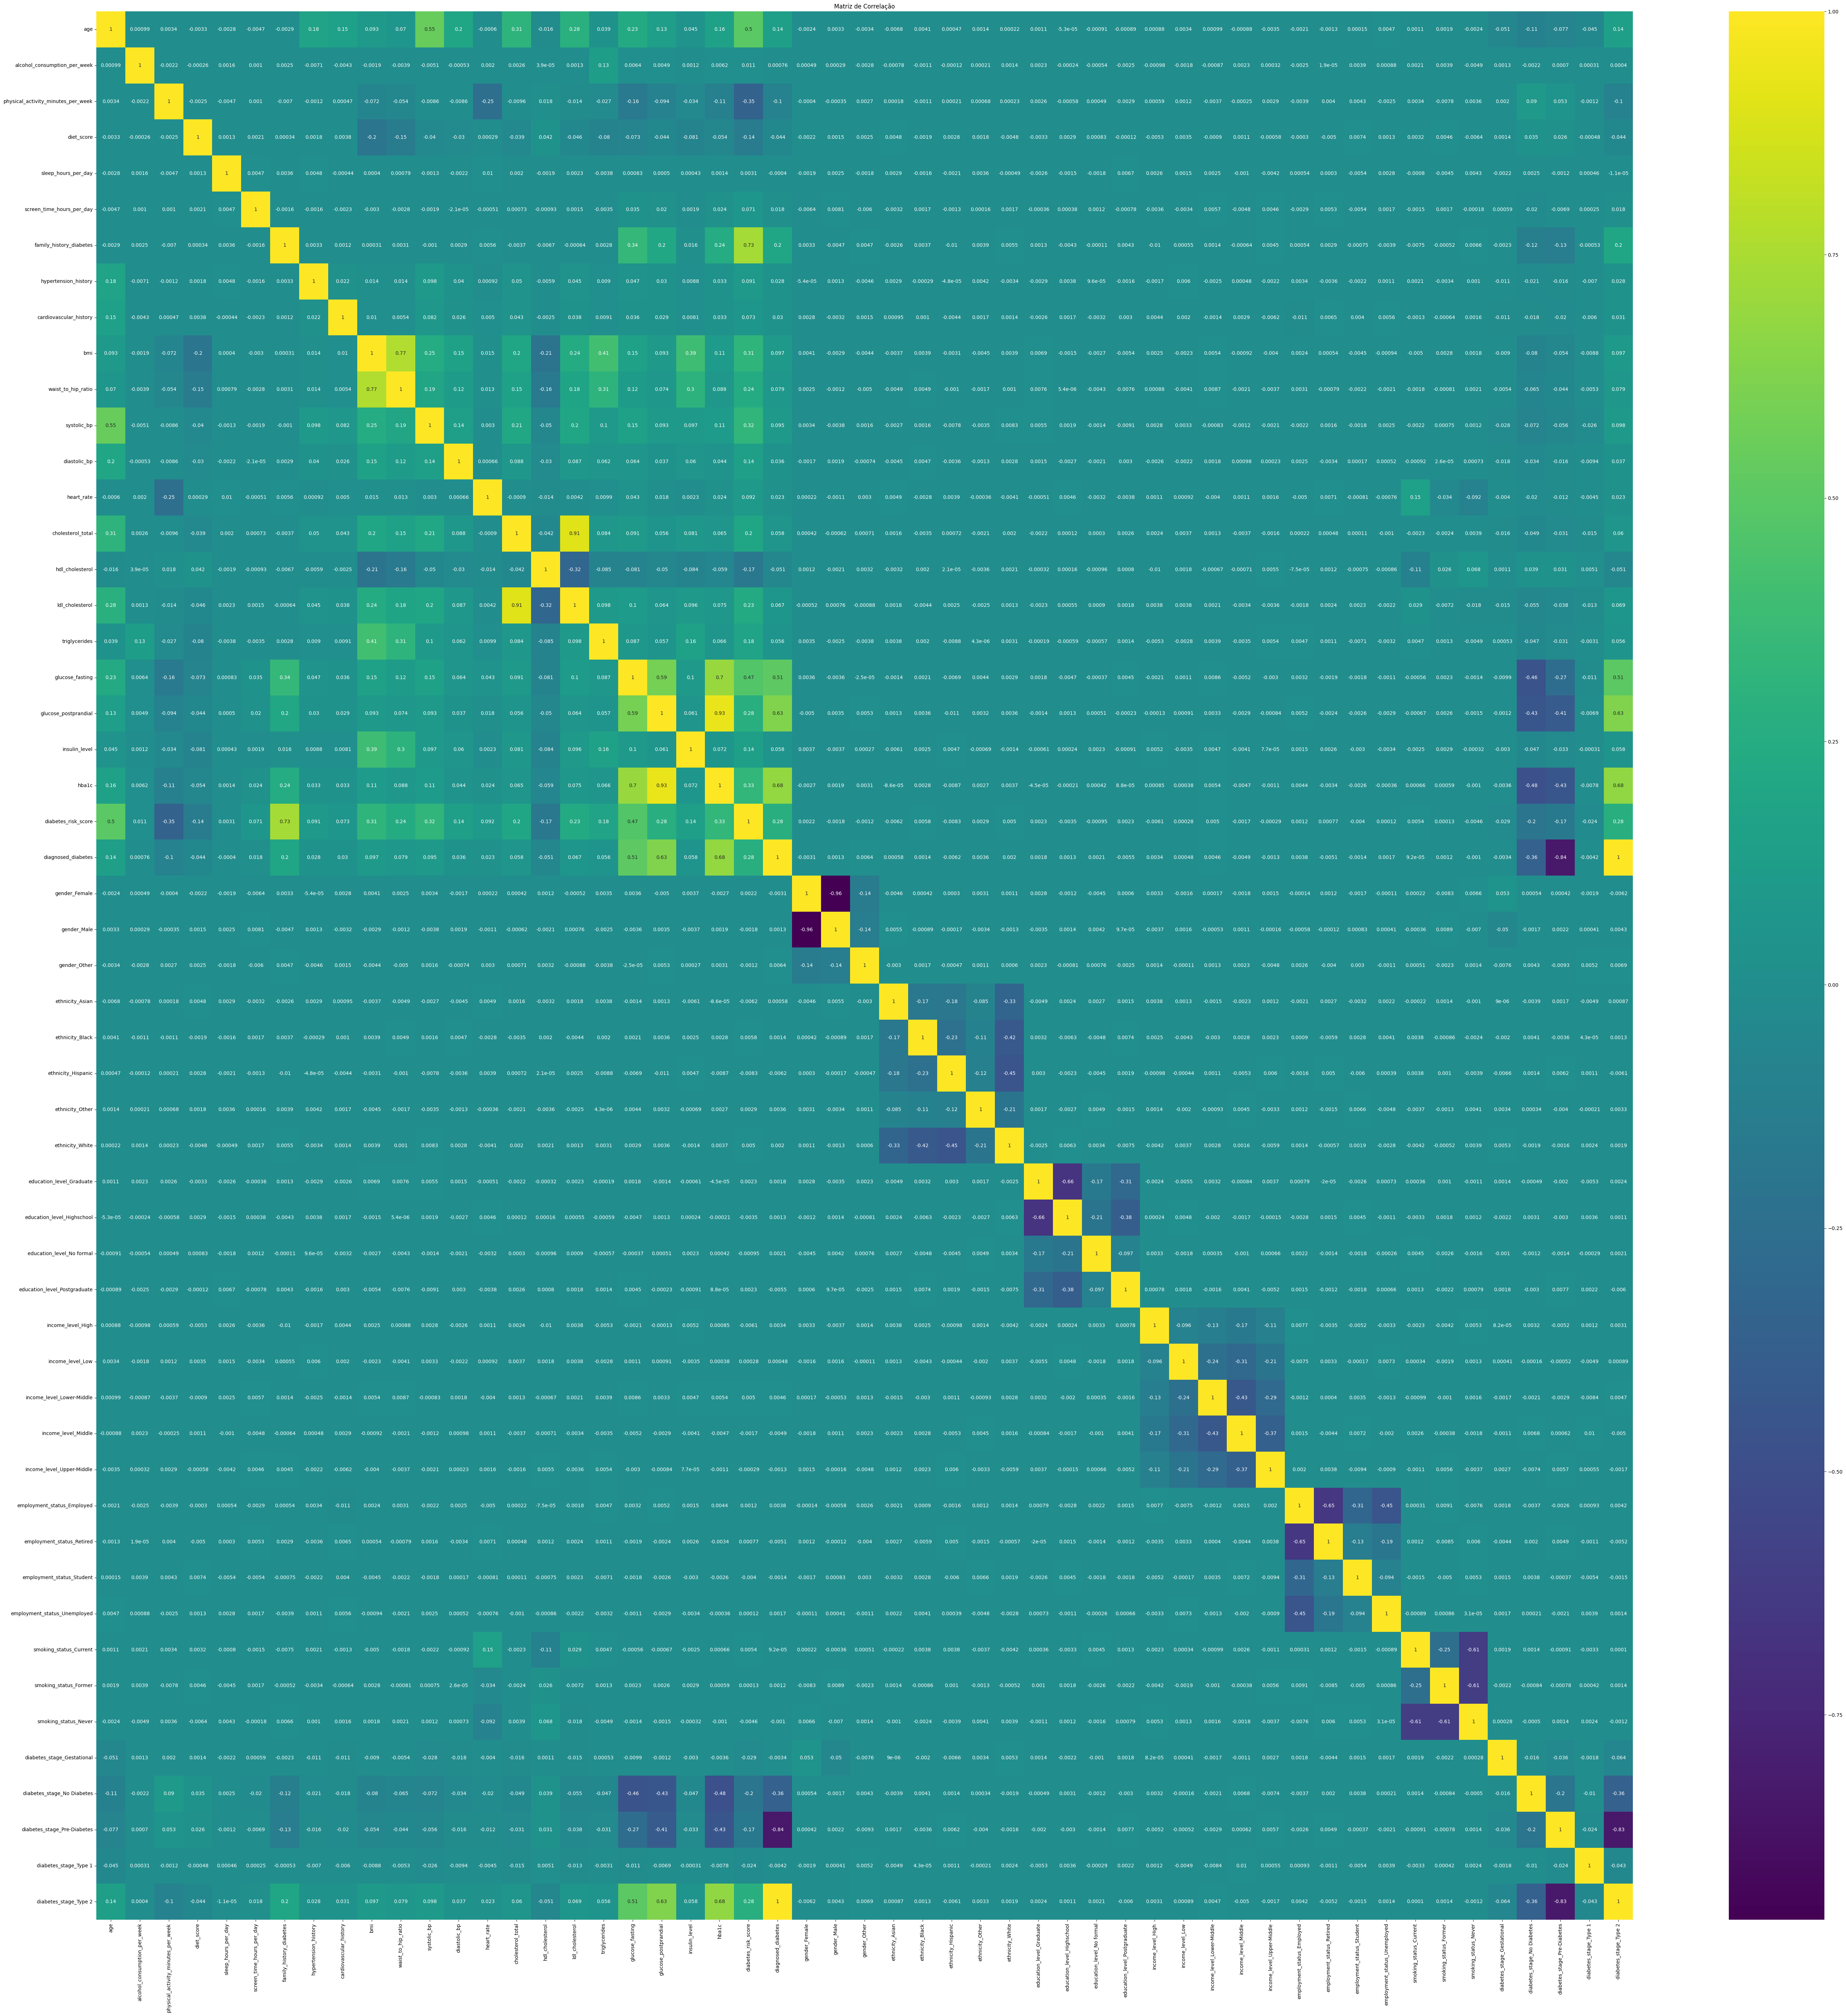

In [10]:
pg.plotar_matriz_correlacao(dataset,(70,70), '../../../reports/figures/matriz_correlacao/matriz_correlacao_diabetes.png')

In [11]:
dataframe_sem_correlacao, removidas = pp.remover_features_correlacionadas(
    dataset,
    limiar=0.7
)

Colunas com correlação >= 0.7:

- waist_to_hip_ratio está altamente correlacionada com bmi (correlação = 0.77)
- ldl_cholesterol está altamente correlacionada com cholesterol_total (correlação = 0.91)
- hba1c está altamente correlacionada com glucose_postprandial (correlação = 0.93)
- diabetes_risk_score está altamente correlacionada com family_history_diabetes (correlação = 0.73)
- gender_Male está altamente correlacionada com gender_Female (correlação = 0.96)
- diabetes_stage_Pre-Diabetes está altamente correlacionada com diagnosed_diabetes (correlação = 0.84)
- diabetes_stage_Type 2 está altamente correlacionada com diagnosed_diabetes (correlação = 1.00)


In [12]:
removidas

['waist_to_hip_ratio',
 'ldl_cholesterol',
 'hba1c',
 'diabetes_risk_score',
 'gender_Male',
 'diabetes_stage_Pre-Diabetes',
 'diabetes_stage_Type 2']

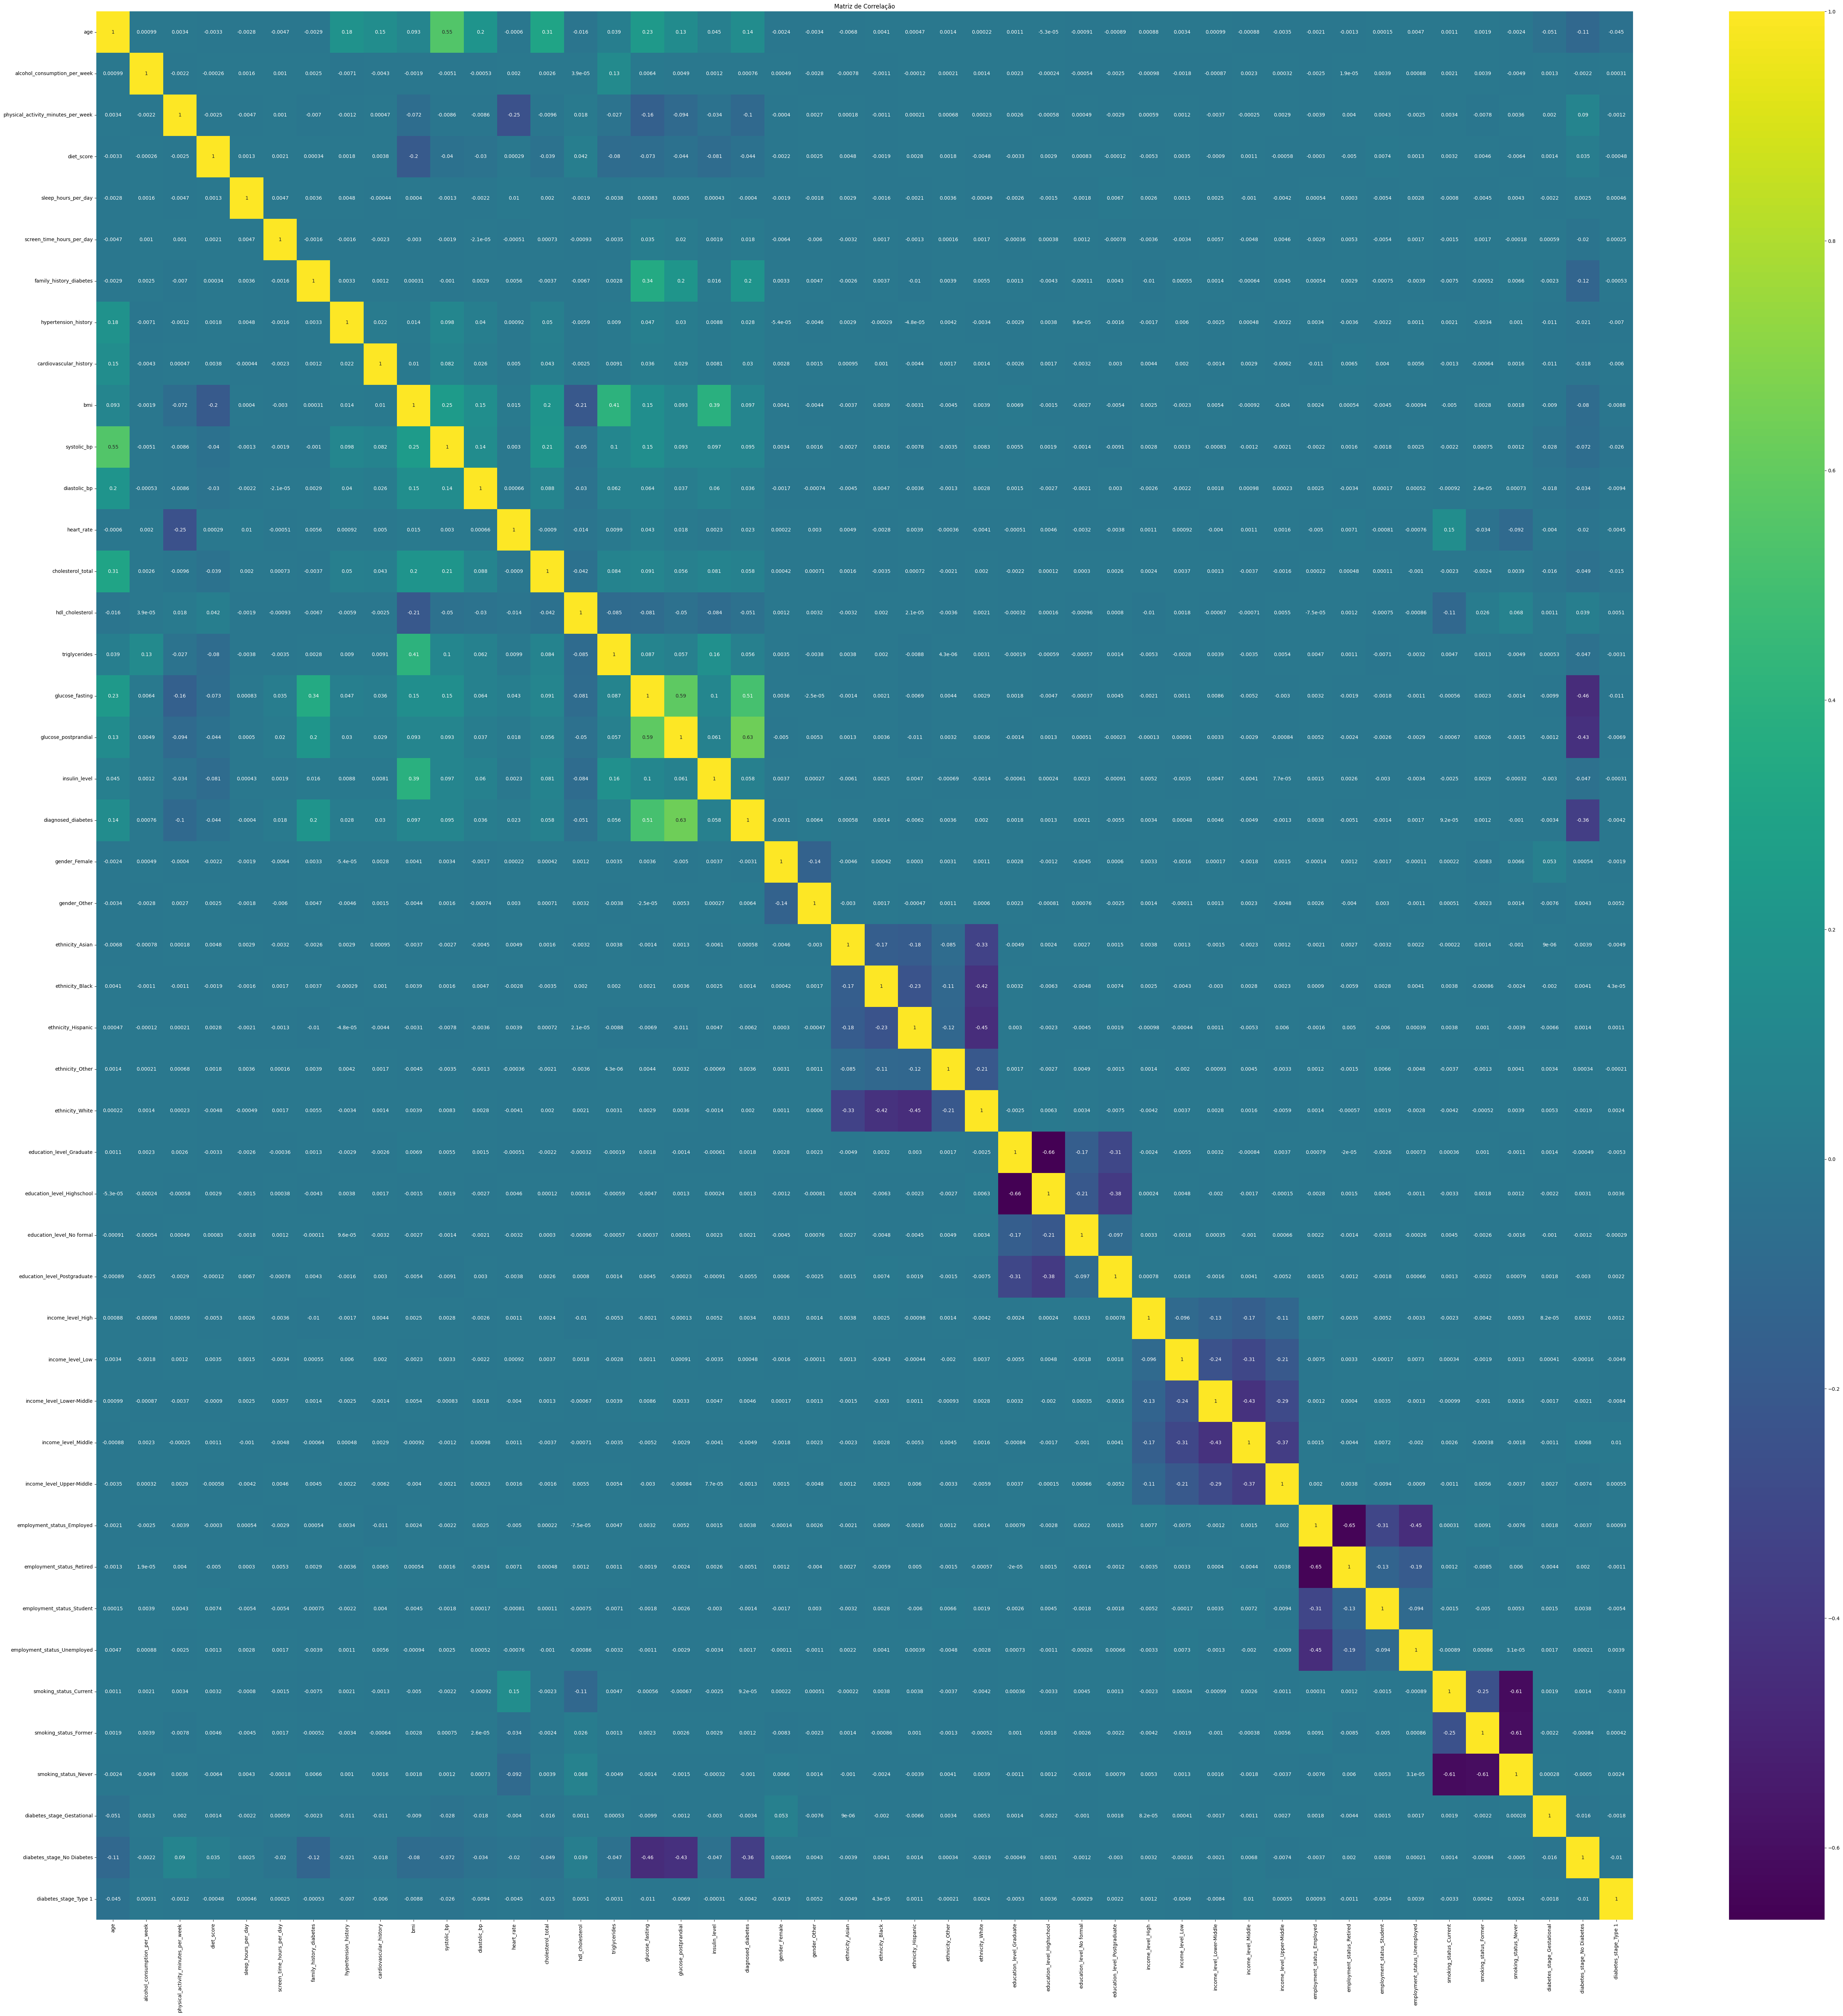

In [13]:
pg.plotar_matriz_correlacao(dataframe_sem_correlacao,(70,70),'../../../reports/figures/matriz_correlacao/matriz_correlacao_removida.png')

In [14]:
dataframe_sem_correlacao

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,employment_status_Employed,employment_status_Retired,employment_status_Student,employment_status_Unemployed,smoking_status_Current,smoking_status_Former,smoking_status_Never,diabetes_stage_Gestational,diabetes_stage_No Diabetes,diabetes_stage_Type 1
0,58,0,215,5.7,7.9,7.9,0,0,0,30.5,...,1,0,0,0,0,0,1,0,0,0
1,48,1,143,6.7,6.5,8.7,0,0,0,23.1,...,1,0,0,0,0,1,0,0,1,0
2,60,1,57,6.4,10.0,8.1,1,0,0,22.2,...,0,0,0,1,0,0,1,0,0,0
3,74,0,49,3.4,6.6,5.2,0,0,0,26.8,...,0,1,0,0,0,0,1,0,0,0
4,46,1,109,7.2,7.4,5.0,0,0,0,21.2,...,0,1,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,1,136,8.3,6.4,4.5,0,0,0,29.8,...,0,0,0,1,0,1,0,0,0,0
99996,41,3,76,8.8,6.8,4.8,0,0,0,26.5,...,1,0,0,0,0,0,1,0,0,0
99997,57,4,121,9.9,5.0,6.1,0,0,1,25.6,...,1,0,0,0,0,1,0,0,1,0
99998,47,3,52,5.9,6.7,0.5,0,1,0,26.8,...,0,1,0,0,0,0,1,0,0,0


In [15]:
# Variável alvo
y = dataframe_sem_correlacao['diagnosed_diabetes']

# Variáveis explicativas
X = dataframe_sem_correlacao.drop(columns=['diagnosed_diabetes'])

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)

Dimensão de X: (100000, 45)
Dimensão de y: (100000,)


In [16]:
features_names = X.columns

In [17]:
features_names

Index(['age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'systolic_bp', 'diastolic_bp',
       'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'triglycerides',
       'glucose_fasting', 'glucose_postprandial', 'insulin_level',
       'gender_Female', 'gender_Other', 'ethnicity_Asian', 'ethnicity_Black',
       'ethnicity_Hispanic', 'ethnicity_Other', 'ethnicity_White',
       'education_level_Graduate', 'education_level_Highschool',
       'education_level_No formal', 'education_level_Postgraduate',
       'income_level_High', 'income_level_Low', 'income_level_Lower-Middle',
       'income_level_Middle', 'income_level_Upper-Middle',
       'employment_status_Employed', 'employment_status_Retired',
       'employment_status_Student', 'employment_status_Unemployed',
       'smokin

In [18]:
resultados = exp.kfold_gridsearch_classificacao(X,y, features_names)


===== Fold 1 =====


KNN | Melhor F1 (val): 0.6604 | Params: {'metric': 'manhattan', 'n_neighbors': 11}
DT | Melhor F1 (val): 0.8400 | Params: {'class_weight': 'balanced', 'max_depth': 8}
LR | Melhor F1 (val): 0.8338 | Params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
RF | Melhor F1 (val): 0.8368 | Params: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 100}
SVM | Melhor F1 (val): 0.8346 | Params: {'C': 0.1, 'class_weight': 'balanced', 'kernel': 'linear'}

===== Fold 2 =====
KNN | Melhor F1 (val): 0.6673 | Params: {'metric': 'manhattan', 'n_neighbors': 9}
DT | Melhor F1 (val): 0.8449 | Params: {'class_weight': 'balanced', 'max_depth': 7}
LR | Melhor F1 (val): 0.8363 | Params: {'C': 1, 'class_weight': 'balanced', 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
RF | Melhor F1 (val): 0.8410 | Params: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}
SVM | Melhor F1 (val): 0.8401 | Params: {'C': 10, 'class_weight': 'balance

In [21]:
df_resultados = pp.resultados_para_dataframe(resultados)
df_resultados.to_csv("resultados_kfold.csv", index=False)


In [22]:
df_comparacao = pp.tabela_metricas_medias(resultados)
print(df_comparacao)

  Modelo  Accuracy Média  Precision Média  Recall Médio  F1-score Médio  \
0     DT         0.84512         0.841769      0.855464        0.842878   
1     RF         0.84484         0.838305      0.848285        0.841114   
2    SVM         0.84226         0.836184      0.847617        0.838976   
3     LR         0.84188         0.834509      0.842304        0.837376   
4    KNN         0.70307         0.696365      0.666978        0.670578   

                                    Melhor Parâmetro  
0       {'class_weight': 'balanced', 'max_depth': 7}  
1  {'class_weight': 'balanced', 'max_depth': 10, ...  
2  {'C': 10, 'class_weight': 'balanced', 'kernel'...  
3  {'C': 1, 'class_weight': 'balanced', 'max_iter...  
4          {'metric': 'manhattan', 'n_neighbors': 9}  


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
best_model = DecisionTreeClassifier(class_weight='balanced',max_depth=7,random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}\n")

print("Relatório de Classificação:")
print(classification_report(y_test, y_pred))

F1-Score: 0.8587

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82      8077
           1       0.93      0.80      0.86     11923

    accuracy                           0.84     20000
   macro avg       0.84      0.85      0.84     20000
weighted avg       0.86      0.84      0.84     20000



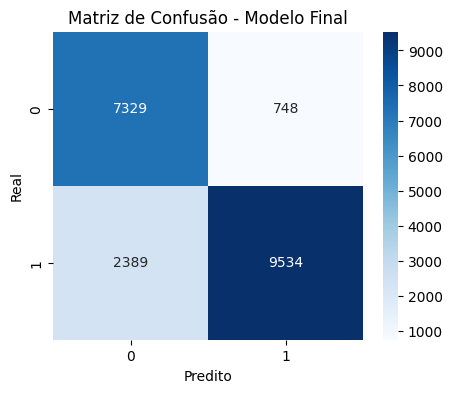

In [25]:
pg.plot_matriz_confusao(y_test, y_pred, '../../../reports/figures/matriz_confusao/matriz_confusao_diabetes_classificador.png')

In [71]:
pg.gerar_e_salvar_shap_bar_duas_classes(X,y)

Salvo: ..\..\..\reports\figures\SHAP_diabetes\SHAP_bar_classe0.png
Salvo: ..\..\..\reports\figures\SHAP_diabetes\SHAP_bar_classe1.png
